In [2]:
import requests
from bs4 import BeautifulSoup

url = 'https://skulddata.cs.umass.edu/traces/mmsys/2013/pathbandwidth/' # Replace with the URL you want to scrape
response = requests.get(url)
html_content = response.text

soup = BeautifulSoup(html_content, 'html.parser')
def gethtml(uxx):
  response = requests.get(uxx)
  return BeautifulSoup(response.text, 'html.parser')

for l in soup.find_all('a'):
    if l.get_text() == "LOGS":
      n = l.get('href')[2:]
      #print('fecthing',url + n)
      s_ = gethtml(url + n)
      k = 0

      for l2 in s_.find_all('a'):
        if "report" in l2.get_text():
          n_ = l2.get('href')
          #print('fecthing2',url + n + '/' + n_)
          response = requests.get(url + n + '/' + n_)
          with open(n + '.' + n_, "w") as f:
              f.write(response.text)
          k += 1

      print(n,k)
'''
bus.ljansbakken-oslo 17
metro.kalbakken-jernbanetorget 17
tram.ljabru-jernbanetorget 15
tram.jernbanetorget-ljabru 8
tram.jernbanetorget-universitetssykehuset 1
ferry.nesoddtangen-oslo 16
car.aarnes-elverum 1
car.oslo-grimstad 1
car.snaroya-smestad 5
train.oslo-vestby 2
train.vestby-oslo 3
'''
#!zip norway_raw.zip *.log

In [ ]:
import glob
H = {"bus.ljansbakken-oslo":17,
     "metro.kalbakken-jernbanetorget":17,
     "tram.ljabru-jernbanetorget":15,
     "tram.jernbanetorget-ljabru":8,
     "tram.jernbanetorget-universitetssykehuset":1,
     "ferry.nesoddtangen-oslo":16,
     "car.aarnes-elverum":1,
     "car.oslo-grimstad":1,
     "car.snaroya-smestad":5,
     "train.oslo-vestby":2,
     "train.vestby-oslo":3}
extracted_data = {}
for route_name in H:
    log_files = glob.glob(f'{route_name}.*.log')
    extracted_data[route_name] = []
    for log_file in log_files:
        with open(log_file, 'r') as f:
            for line in f:
                columns = line.strip().split()
                try:
                    extracted_tuple = (float(columns[2]), float(columns[3]))
                    extracted_data[route_name].append(extracted_tuple)
                except IndexError:
                    print(f"{log_file} Skipping malformed line: {line.strip()}")
                    continue
                except ValueError:
                    print(f"{log_file} Skipping malformed line: {line.strip()}")
                    continue
        break
    #extracted_data[route_name].sort()

print("Log files processed and data extracted into 'extracted_data'.")
if extracted_data:
    sample_route = next(iter(extracted_data))
    print(f"Sample data for '{sample_route}': {extracted_data[sample_route][:5]} (showing first 5 entries)")

In [61]:
import folium
if extracted_data:
    sample_route_name =  "metro.kalbakken-jernbanetorget"
    sample_route_coords = extracted_data[sample_route_name]

    if sample_route_coords:
        min_lat = min(coord[0] for coord in sample_route_coords)
        max_lat = max(coord[0] for coord in sample_route_coords)
        min_lon = min(coord[1] for coord in sample_route_coords)
        max_lon = max(coord[1] for coord in sample_route_coords)
        bounds = [(min_lat, min_lon), (max_lat, max_lon)]

        m = folium.Map()
        m.fit_bounds(bounds);

        # PolyLine to represent the route
        folium.PolyLine(sample_route_coords, color="magenta", weight=5, opacity=1).add_to(m)

        # 'Start'
        folium.Marker( location=sample_route_coords[0], icon=folium.Icon(color='green', icon='play'), popup='Start' ).add_to(m)

        # 'End' marker
        folium.Marker( location=sample_route_coords[-1], icon=folium.Icon(color='red', icon='stop'),popup='End').add_to(m)


        print(f"Map generated for route: {sample_route_name}. Displaying map...")
        # Display the map
        display(m)

        m.save(sample_route_name + ".html")
        print('saved', sample_route_name)
    else:
        print(f"No valid coordinates found for the sample route: {sample_route_name}")
else:
    print("No processed data available to plot.")

Map generated for route: metro.kalbakken-jernbanetorget. Displaying map...


saved metro.kalbakken-jernbanetorget


# Task
The previous steps successfully scraped the log files and extracted latitude and longitude coordinates for some routes. However, the plan requires extracting bandwidth data (from the 5th and 6th columns) and calculating bandwidth, then storing these as `(rounded_lat, rounded_lon, bandwidth)` tuples. The current extraction logic only extracts latitude and longitude and only processes one log file per route.

Let's modify the data extraction cell to fully implement the "Extract Bandwidth and Location Data" step. This involves:

1.  Initializing a new dictionary `bandwidth_data_per_route`.
2.  Iterating through all log files for each route.
3.  Extracting latitude (column 2), longitude (column 3), 5th column, and 6th column.
4.  Converting these to float and rounding latitude/longitude to 4 decimal places.
5.  Calculating bandwidth as `(8 * 5th_column_float) / 6th_column_float`.
6.  Handling potential errors (e.g., `IndexError` for malformed lines, `ValueError` for non-numeric data).
7.  Storing the `(rounded_lat, rounded_lon, bandwidth)` tuples in `bandwidth_data_per_route`.

```python
import glob

# H is already defined from the previous state, no need to redefine
# H = {"bus.ljansbakken-oslo":17, ... }

bandwidth_data_per_route = {}

for route_name in H:
    log_files = glob.glob(f'{route_name}.*.log')
    bandwidth_data_per_route[route_name] = [] # Initialize list for each route

    for log_file in log_files:
        with open(log_file, 'r') as f:
            for line in f:
                columns = line.strip().split()
                try:
                    # Ensure enough columns exist
                    if len(columns) < 6:
                        print(f"Skipping malformed line (insufficient columns) in {log_file}: {line.strip()}")
                        continue

                    # Extract and convert data
                    lat = float(columns[2])
                    lon = float(columns[3])
                    fifth_column = float(columns[4])
                    sixth_column = float(columns[5])

                    # Round latitude and longitude to 4 decimal places
                    rounded_lat = round(lat, 4)
                    rounded_lon = round(lon, 4)

                    # Calculate bandwidth
                    # Avoid division by zero
                    if sixth_column == 0:
                        print(f"Skipping line with zero in 6th column (division by zero) in {log_file}: {line.strip()}")
                        continue
                    bandwidth = (8 * fifth_column) / sixth_column

                    # Store the tuple
                    bandwidth_data_per_route[route_name].append((rounded_lat, rounded_lon, bandwidth))

                except (IndexError, ValueError) as e:
                    print(f"Skipping malformed line in {log_file} due to error ({e}): {line.strip()}")
                    continue

print("All log files processed and bandwidth data extracted into 'bandwidth_data_per_route'.")

# Display a sample of the extracted data
if bandwidth_data_per_route:
    sample_route = next(iter(bandwidth_data_per_route))
    print(f"\nSample data for '{sample_route}' (first 5 entries):")
    for entry in bandwidth_data_per_route[sample_route][:5]:
        print(entry)
else:
    print("\nNo bandwidth data was extracted.")
```

In [ ]:
import glob
import statistics

bandwidth_data_per_route = {}
location_bandwidth_values = {}

for route_name in H:
    bandwidth_data_per_route[route_name] = []
    for log_file in glob.glob(f'{route_name}.*.log'):
        with open(log_file, 'r') as f:
            for line in f:
                columns = line.strip().split()
                try:
                    if len(columns) < 6:
                        print(f"Skipping malformed line in {log_file}: Not enough columns. Line: {line.strip()}")
                        continue

                    lat = float(columns[2])
                    lon = float(columns[3])
                    fifth_column_float = float(columns[4])
                    sixth_column_float = float(columns[5])

                    rounded_lat = round(lat, 4)
                    rounded_lon = round(lon, 4)

                    if sixth_column_float == 0:
                        print(f"Skipping line in {log_file}: Division by zero for bandwidth calculation. Line: {line.strip()}")
                        continue

                    bandwidth = (8 * fifth_column_float / 1000) / sixth_column_float
                    bandwidth_data_per_route[route_name].append((rounded_lat, rounded_lon, bandwidth))

                    location_tuple = (lat, lon)
                    if location_tuple not in location_bandwidth_values: location_bandwidth_values[location_tuple] = []
                    location_bandwidth_values[location_tuple].append(bandwidth)

                except (IndexError, ValueError) as e:
                    print(f"Skipping malformed line in {log_file} due to: {e}. Line: {line.strip()}")
                    continue

print("Log files processed and bandwidth data extracted into 'bandwidth_data_per_route'.")





In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

plt.figure(figsize=(15, 10))

route_name = "train.vestby-oslo" # The currently selected route from the previous turn
if route_name not in bandwidth_data_per_route or not bandwidth_data_per_route[route_name]:
    print(f"No data to plot for route: {route_name}")
else:
    data_list = bandwidth_data_per_route[route_name]
    data_list_sorted = sorted(data_list, key=lambda x: x[1]) # Sort by longitude

    lons = [item[1] for item in data_list_sorted]
    bandwidths = [item[2] for item in data_list_sorted]

    if len(lons) < 2:
        print(f"Not enough data points to create a step graph for route: {route_name}")
    else:
        segments = []
        segment_colors = []

        # Create segments for a 'post' step plot and assign colors based on bandwidth
        for i in range(len(lons) - 1):
            # Horizontal segment: (lons[i], bandwidths[i]) to (lons[i+1], bandwidths[i])
            segments.append([(lons[i], bandwidths[i]), (lons[i+1], bandwidths[i])])
            segment_colors.append(bandwidths[i])

            # Vertical segment: (lons[i+1], bandwidths[i]) to (lons[i+1], bandwidths[i+1])
            # Color this vertical segment by the new bandwidth value (bandwidths[i+1])
            if bandwidths[i] != bandwidths[i+1]:
                segments.append([(lons[i+1], bandwidths[i]), (lons[i+1], bandwidths[i+1])])
                segment_colors.append(bandwidths[i+1])

        # Determine min and max bandwidths for normalization (from this route's data)
        min_band = min(segment_colors) if segment_colors else 0
        max_band = max(segment_colors) if segment_colors else 1

        # Using viridis colormap with 10 discrete levels as requested
        cmap = plt.cm.get_cmap('viridis', 10)
        norm = Normalize(vmin=min_band, vmax=max_band)

        # Create LineCollection with the segments and their colors
        line_collection = LineCollection(segments, cmap=cmap, norm=norm, linewidth=3, alpha=0.9)
        line_collection.set_array(np.array(segment_colors))

        ax = plt.gca()
        ax.add_collection(line_collection)

        # Set plot limits, labels, and title
        ax.set_xlim(min(lons) * 0.99, max(lons) * 1.01) # Add slight padding
        ax.set_ylim(min(bandwidths) * 0.9, max(bandwidths) * 1.1) # Add slight padding

        plt.xlabel('Longitude')
        plt.ylabel('Bandwidth (Mbps)')
        plt.title(f'Bandwidth Distribution for {route_name} (Dynamic Step Graph)')
        plt.grid(True, linestyle='--', alpha=0.6)

        # Add colorbar to interpret the colors
        cbar = plt.colorbar(line_collection, ax=ax)
        cbar.set_label('Bandwidth (Mbps)')

        plt.tight_layout()
        plt.show()

print(f"Dynamically colored step graph for route '{route_name}' generated.")

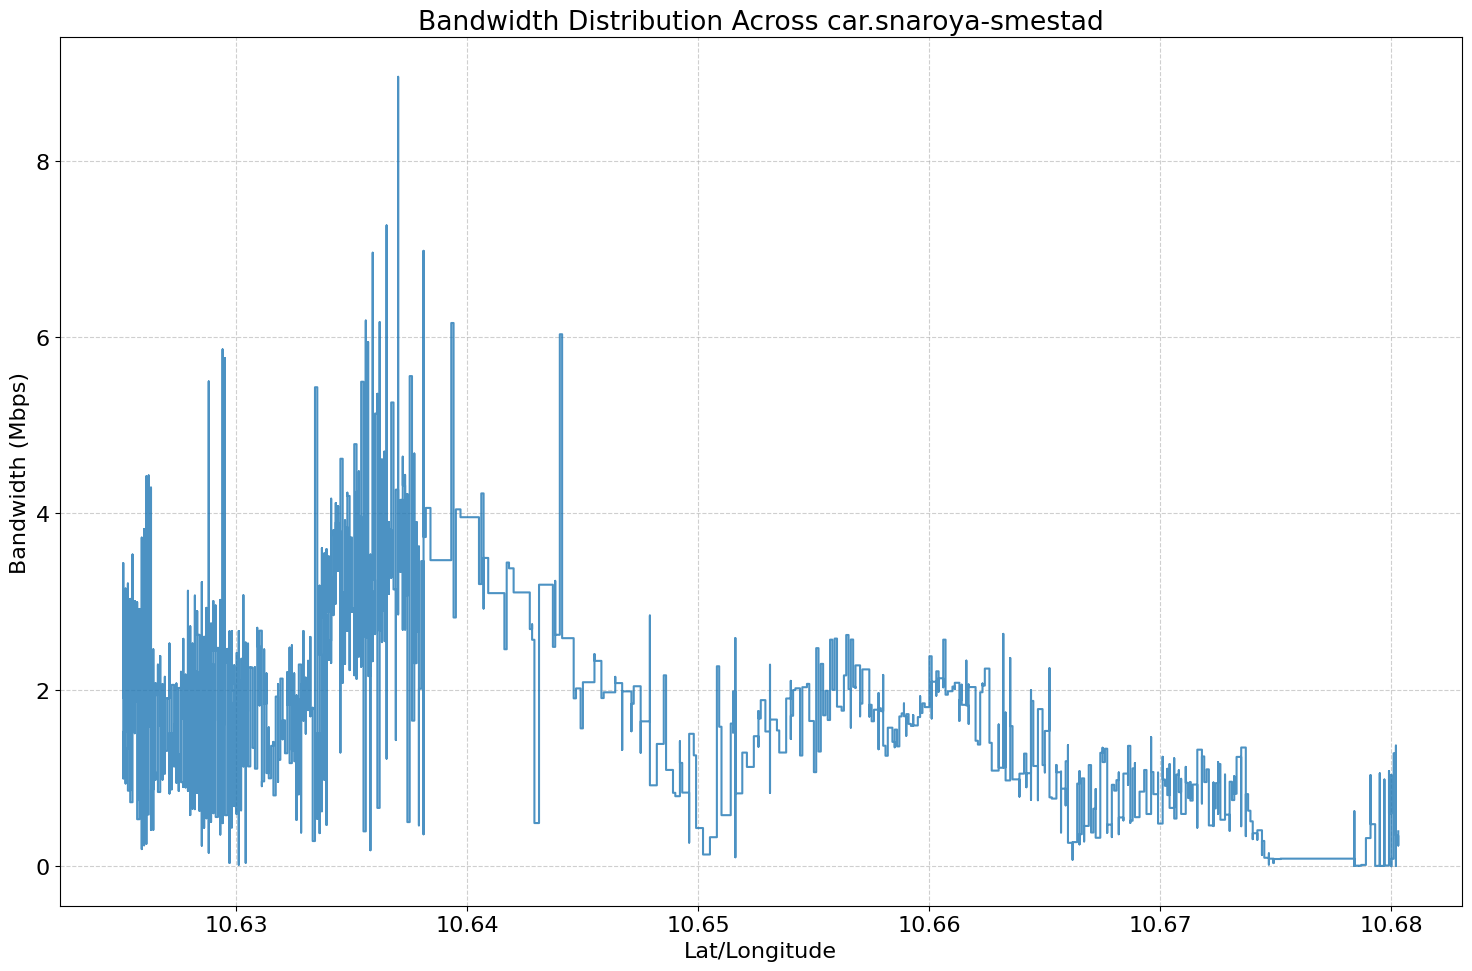

In [89]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({'font.size': 16})
H = {"bus.ljansbakken-oslo":17,
     "metro.kalbakken-jernbanetorget":17,
     "tram.ljabru-jernbanetorget":15,
     "tram.jernbanetorget-ljabru":8,
     "tram.jernbanetorget-universitetssykehuset":1,
     "ferry.nesoddtangen-oslo":16,
     "car.aarnes-elverum":1,
     "car.oslo-grimstad":1,
     "car.snaroya-smestad":5,
     "train.oslo-vestby":2,
     "train.vestby-oslo":3}

plt.figure(figsize=(15, 10))

# Define a colormap (though individual colors for routes will be used with plt.step)
cmap = plt.cm.viridis # Not directly used for step plot colors, but can be for other visualizations

route_name = "car.snaroya-smestad"
data_list = bandwidth_data_per_route[route_name]
data_list_sorted = sorted(data_list, key=lambda x: x[1]) # Sort by longitude
lats = [item[0] for item in data_list_sorted]
lons = [item[1] for item in data_list_sorted]
bandwidths = [item[2] for item in data_list_sorted]

plt.step(lons, bandwidths, label=route_name, alpha=0.8, where='post') # 'post' makes steps at data points


plt.xlabel('Lat/Longitude')
plt.ylabel('Bandwidth (Mbps)')
plt.title('Bandwidth Distribution Across ' + route_name)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
